In [ ]:
import pandas as pd
import numpy as np
import altair as alt
import matplotlib.pyplot as plt


In [ ]:
obesity = pd.read_csv('obese_pop_csv.csv')
obesity['Percentage of Obese Population'] = obesity['Percentage of Obese Population'] / 100
#print(obesity)

pop_weight = pd.DataFrame()
pop_weight['County'] = obesity['County']
pop_weight['Year'] = obesity['Year']

pop_weight['Total Adult Population'] = obesity['Total Obese Population'] / obesity['Percentage of Obese Population']
pop_weight['Total Adult Population'] = np.floor(pop_weight['Total Adult Population'])
print(pop_weight['Total Adult Population'])
tot_pop = pd.DataFrame()
tot_pop = pop_weight.tail(13)
pop_weight = pop_weight.head(572)

repeated_total = pd.concat([tot_pop] * 44, ignore_index=True)

pop_weight['Ratio of Adult Population'] = pop_weight['Total Adult Population'] / repeated_total['Total Adult Population']

pop_weight.to_csv('adult_population_ratio.csv')
pop_weight

0        170700.0
1        170731.0
2        170124.0
3        174734.0
4        175980.0
          ...    
580    29678756.0
581    29689432.0
582    29633893.0
583    29592783.0
584    29213730.0
Name: Total Adult Population, Length: 585, dtype: float64


,County,Year,Total Adult Population,Ratio of Adult Population
0,Butte,2011,170700.0,0.006271
1,Butte,2012,170731.0,0.006146
2,Butte,2013,170124.0,0.006043
3,Butte,2014,174734.0,0.006117
4,Butte,2015,175980.0,0.006049
...,...,...,...,...
567,Imperial,2019,124267.0,0.004187
568,Imperial,2020,123529.0,0.004161
569,Imperial,2021,121527.0,0.004101
570,Imperial,2022,117848.0,0.003982


In [ ]:
df = pd.read_csv('California_obesity_demographics_COMPLETE_UPDATED.csv')
df

,Unnamed: 0,County,Year,Percentage of Obese Population,Total Obese Population,Percentage of Population that is Latino,Total Latino Population,Percentage of Population that is White,Total White Population,Percentage of Population that is Black,...,% of Population insured through Medicaid,Total Population insured through Medicaid,% of Population insured through Healthy Families/ CHIP,Total Population insured through Healthy Families/ CHIP,% of Population insured through Employment,Total Population insured through Employment,% of Population insured Privately,Total Population insured Privately,% of Population with Other Public Insurance,Total Population with Other Public Insurance
0,0,Butte,2011,78.5,134000,14.7,32000,77.2,167000,0.0,...,20.2,44000,0.0,0,38.5,83000,4.0,9000,2.6,6000
1,1,Butte,2012,73.8,126000,15.9,34000,70.0,151000,2.3,...,16.7,36000,1.3,3000,40.0,86000,2.0,4000,2.2,5000
2,2,Butte,2013,72.3,123000,18.9,41000,73.0,158000,0.0,...,18.4,40000,0.0,0,44.2,96000,2.6,6000,0.0,0
3,3,Butte,2014,84.7,148000,15.4,34000,74.5,163000,1.7,...,27.5,60000,0.0,0,44.2,97000,3.4,8000,0.0,0
4,4,Butte,2015,84.1,148000,15.2,32000,72.8,156000,0.0,...,26.7,57000,0.0,0,44.1,95000,6.2,13000,0.7,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,567,Imperial,2019,85.3,106000,82.8,146000,12.8,23000,0.0,...,41.3,73000,0.0,0,37.0,65000,5.3,9000,0.0,0
568,568,Imperial,2020,85.0,105000,82.8,145000,12.7,22000,0.0,...,41.2,72000,0.0,0,29.5,52000,7.9,14000,0.0,0
569,569,Imperial,2021,86.4,105000,83.2,144000,12.8,22000,0.0,...,49.1,85000,0.0,0,30.3,52000,4.2,7000,1.4,2000
570,570,Imperial,2022,87.4,103000,83.2,139000,12.7,21000,0.0,...,34.2,57000,0.0,0,42.1,70000,2.1,4000,0.0,0


In [ ]:
df = df[['County', 'Year', 'Percentage of Obese Population']]

test_counties = df[df['County'].isin(['San Francisco', 'Alameda', 'Albany'])]
test_counties = test_counties.reset_index(drop = True)
test_counties
other_counties = df[~df['County'].isin(['San Francisco', 'Alameda', 'Albany'])]
other_counties = other_counties.reset_index(drop = True)

avg_other = other_counties.groupby('Year')['Percentage of Obese Population'].mean()
avg_other
avg_test = test_counties.groupby('Year')['Percentage of Obese Population'].mean()
avg_test = pd.DataFrame(avg_test)
avg_test
avg_other

,Percentage of Obese Population
Year,
2011,78.973810
2012,78.976190
2013,78.971429
2014,80.373810
2015,79.745238
2016,80.573810
2017,77.650000
2018,77.595238
2019,78.990476


In [ ]:
pred_df = pd.read_csv('my_pred(in).csv', index_col = False)
years = [2018, 2019, 2020, 2021, 2022, 2023]

pred_df.insert(loc = 1, column = 'Year', value = years)
pred_df = pred_df.reset_index(drop = True)
pred_df = pred_df[['Year', 'prediction_mc']].reset_index(drop = True)
pred_df.columns = ['Year', 'Percentage of Obese Population']
pred_df = pred_df.set_index('Year')

test_pred = avg_test.head(7)

test_pred = pd.concat([test_pred, pred_df])
test_pred.columns = ['Predicted Percentage of Obese Population']
test_pred

,Predicted Percentage of Obese Population
Year,
2011,69.750000
2012,66.850000
2013,69.150000
2014,71.450000
2015,72.100000
2016,74.300000
2017,66.450000
2018,70.946277
2019,71.475054


In [ ]:
avg_other.columns = ['Other County Average']
avg_test.columns = ['Test County Average']

results = pd.DataFrame()
results['Test County Average'] = avg_test
results['Other County Average'] = avg_other
results['Predicted Obesity Rate'] = test_pred

results

,Test County Average,Other County Average,Predicted Obesity Rate
Year,,,
2011,69.75,78.973810,69.750000
2012,66.85,78.976190,66.850000
2013,69.15,78.971429,69.150000
2014,71.45,80.373810,71.450000
2015,72.10,79.745238,72.100000
2016,74.30,80.573810,74.300000
2017,66.45,77.650000,66.450000
2018,70.35,77.595238,70.946277
2019,67.55,78.990476,71.475054


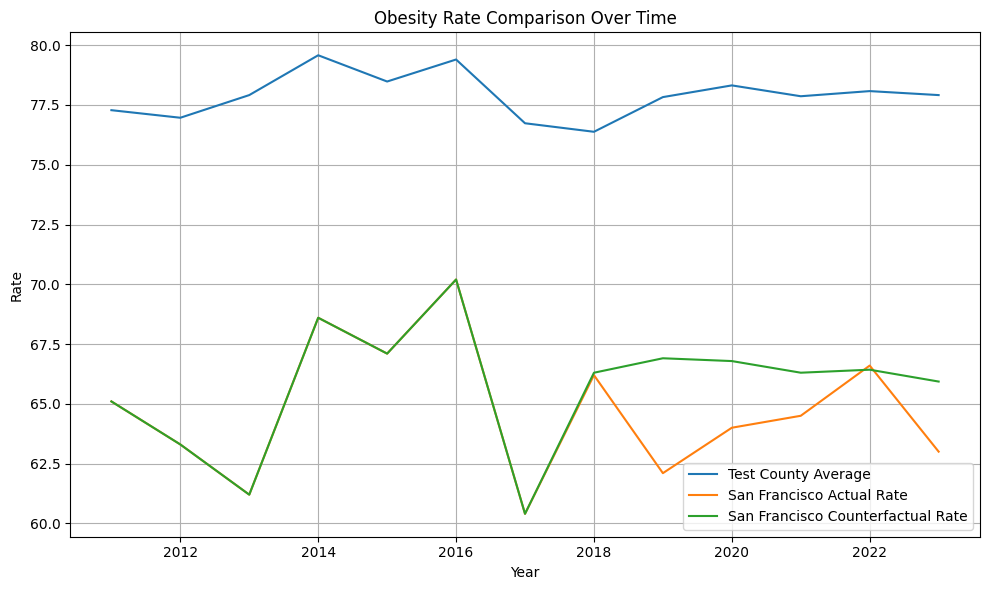

In [ ]:

# Data
data = pd.read_csv('output(in).csv')
data['Year'] = list(range(2011,2024))

df = pd.DataFrame(data)



# Plot
plt.figure(figsize=(10, 6))
plt.plot(df['Year'], df['nosodatax_rate'], label='Test County Average')
plt.plot(df['Year'], df['sf_actural_rate'], label='San Francisco Actual Rate')
plt.plot(df['Year'], df['sf_counterfactual_rate'], label='San Francisco Counterfactual Rate')

plt.title('Obesity Rate Comparison Over Time')
plt.xlabel('Year')
plt.ylabel('Rate (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



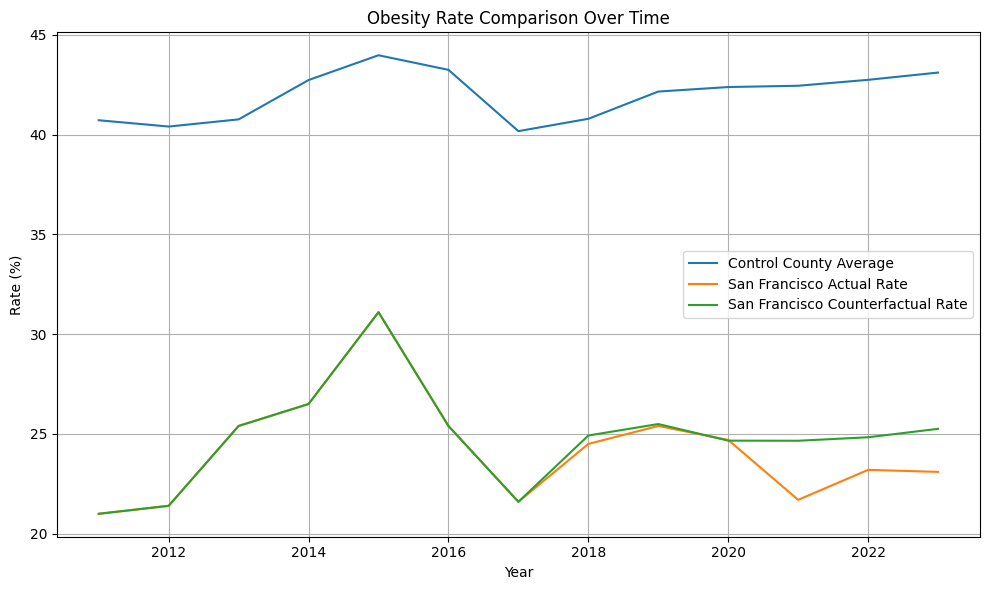

In [ ]:
obese_bmi_df = pd.read_csv('obese_output.csv')
obese_bmi_df['Year'] = list(range(2011,2024))

df = pd.DataFrame(obese_bmi_df)
plt.figure(figsize=(10, 6))
plt.plot(df['Year'], df['nosodatax_rate'], label='Control County Average')
plt.plot(df['Year'], df['sf_actural_rate'], label='San Francisco Actual Rate')
plt.plot(df['Year'], df['sf_counterfactual_rate'], label='San Francisco Counterfactual Rate')

plt.title('Obesity Rate Comparison Over Time')
plt.xlabel('Year')
plt.ylabel('Rate (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()